# LD structure of the rs1047626 SNP and the matching pattern with archaic genomes

# 0. Library and Packages

Packages installd through conda and their version

Python packages

In [1]:
import pandas as pd
import numpy as np
import os
%load_ext rpy2.ipython

R Packages

In [2]:
%%R

library(tidyverse)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# 1. Calculate rs1047626 LD structure in modern humans

## 1.1. Download modern human data (gnomAD harmonized call of HGDP+1000GP dataset)

In [3]:
%%bash

#rm -f hgdp.tgp.gwaspy.merged.chr4.merged.bcf.csi metadata.txt hgdp.tgp.gwaspy.merged.chr4.merged.bcf
#wget https://storage.googleapis.com/gcp-public-data--gnomad/resources/hgdp_1kg/phased_haplotypes/hgdp.tgp.gwaspy.merged.chr4.merged.bcf.csi    -O hgdp.tgp.gwaspy.merged.chr4.merged.bcf.csi -o hgdp.tgp.gwaspy.merged.chr4.merged.bcf.csi.log
#wget https://storage.googleapis.com/gcp-public-data--gnomad/release/3.1/secondary_analyses/hgdp_1kg_v2/metadata_and_qc/gnomad_meta_updated.tsv -O metadata.txt                               -o metadata.txt.log
#wget https://storage.googleapis.com/gcp-public-data--gnomad/resources/hgdp_1kg/phased_haplotypes/hgdp.tgp.gwaspy.merged.chr4.merged.bcf        -O hgdp.tgp.gwaspy.merged.chr4.merged.bcf     -o hgdp.tgp.gwaspy.merged.chr4.merged.bcf.log

## 1.2. Extract relevant metadata information

In [4]:
metadata = pd.read_table("metadata.txt")

/tmp/36118939/ipykernel_1001705/1937215839.py:1: DtypeWarning: Columns (0: sample_filters.hard_filters, 1: sample_filters.release_related, 2: sample_filters.release_duplicate, 3: sample_filters.release_parent_child, 4: sample_filters.release_sibling, 5: sample_filters.all_samples_related, 6: sample_filters.all_samples_duplicate, 7: sample_filters.all_samples_parent_child, 8: sample_filters.all_samples_sibling, 9: sample_filters.fail_n_snp_residual, 10: sample_filters.fail_n_singleton_residual, 11: sample_filters.fail_r_ti_tv_residual, 12: sample_filters.fail_r_insertion_deletion_residual, 13: sample_filters.fail_n_insertion_residual, 14: sample_filters.fail_n_deletion_residual, 15: sample_filters.fail_r_het_hom_var_residual, 16: sample_filters.fail_n_transition_residual, 17: sample_filters.fail_n_transversion_residual, 18: bergstrom.hgdp, 19: bergstrom.lp, 20: bergstrom.source, 21: bergstrom.library_type, 22: bergstrom.region, 23: bergstrom.sex, 24: bergstrom.sample, 25: sample_accessi

Obtain a file with each individual and their sex

In [5]:
metadata[["s", "project_meta.sex"]].to_csv("ind_sex.txt", sep='\t', header=False, index=False)

In [6]:
%%bash

head ind_sex.txt

HGDP00001	male
HGDP00003	male
HGDP00005	male
HGDP00007	male
HGDP00009	male
HGDP00011	male
HGDP00013	male
HGDP00015	male
HGDP00017	male
HGDP00021	male


Obtain a file with the individuals that are unrelated

In [7]:
(pd.DataFrame({"ind" : metadata[metadata["sample_filters.release_related"] == False].s.to_numpy()}).
    to_csv("unrelated.txt", sep='\t', header=False, index=False))

In [8]:
%%bash

head unrelated.txt

HGDP00001
HGDP00003
HGDP00005
HGDP00007
HGDP00009
HGDP00011
HGDP00013
HGDP00015
HGDP00017
HGDP00021


## 1.3. Subsample the region of interest

We sample 250 kb upstream and downstream (500 kb in total) from the rs1047626 SNP. We subset individuals that are unrelated to compute LD. We also annotate the VCF with custom SNP ID for downstream reformating procedure.

In [9]:
%%bash

time bcftools annotate --set-id '%CHROM:%POS' \
                       -S unrelated.txt \
                       -r chr4:41751654-42251654 \
                       -O b \
                       -o hgdp.tgp.gwaspy.merged.chr4.merged.subset.bcf \
                       --write-index \
                       hgdp.tgp.gwaspy.merged.chr4.merged.bcf


real	0m13.161s
user	0m12.441s
sys	0m0.052s


## 1.4 Format data to PLINK format

In [10]:
%%bash

bcftools query -l hgdp.tgp.gwaspy.merged.chr4.merged.subset.bcf > samples.txt

In [11]:
%%R

metadata_file  <- "ind_sex.txt"
ind_list_file  <- "samples.txt"
output_file    <- "plink.psam"


metadata = read.csv(metadata_file, col.names = c("ind", "sex"), sep = "\t") %>% select(IID = ind, SEX = sex)
ind_list = read.csv(ind_list_file, header = FALSE, sep = "\t", col.names = c("IID"))

write_lines("#IID\tSEX", output_file)

ind_list %>%
    left_join(metadata, by = c("IID"))%>%
    mutate(SEX = ifelse(SEX == "male", 1, ifelse(SEX == "female", 2, 0))) %>%
    write.table(file = output_file, sep = "\t", row.names = FALSE, quote = FALSE, append = TRUE, col.names = FALSE)

In [12]:
%%bash

time plink2 --bcf  hgdp.tgp.gwaspy.merged.chr4.merged.subset.bcf \
            --make-pgen \
            --psam plink.psam \
            --out  plink

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to plink.log.
Options in effect:
  --bcf hgdp.tgp.gwaspy.merged.chr4.merged.subset.bcf
  --make-pgen
  --out plink
  --psam plink.psam

Start time: Mon Apr 27 15:29:26 2026
1547877 MiB RAM detected, ~1508957 available; reserving 773938 MiB for main
workspace.
Using 1 compute thread.
--bcf: 26266 variants scanned.
--bcf: plink-temporary.pgen + plink-temporary.pvar.zst written.
4099 samples (1898 females, 2200 males, 1 ambiguous; 4099 founders) loaded from
plink.psam.
26266 variants loaded from plink-temporary.pvar.zst.
Note: No phenotype data present.
Writing plink.psam ... done.
Writing plink.pvar ... done.
Writing plink.pgen ... done.
End time: Mon Apr 27 15:29:27 2026



real	0m1.227s
user	0m0.646s
sys	0m0.423s


## 1.5. Compute LD from rs1047626 to the other SNPs

In [13]:
%%bash

time plink2 --pfile plink \
            --r2-phased \
            --ld-snp chr4:42001654 \
            --ld-window-kb 1000 \
            --ld-window-r2 0 \
            --out ld

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ld.log.
Options in effect:
  --ld-snp chr4:42001654
  --ld-window-kb 1000
  --ld-window-r2 0
  --out ld
  --pfile plink
  --r2-phased

Start time: Mon Apr 27 15:29:27 2026
1547877 MiB RAM detected, ~1508763 available; reserving 773938 MiB for main
workspace.
Using 1 compute thread.
4099 samples (1898 females, 2200 males, 1 ambiguous; 4099 founders) loaded from
plink.psam.
26266 variants loaded from plink.pvar.
Note: No phenotype data present.
Calculating allele frequencies... done.
Running --r2-phased with the following filters:
  --ld-window-kb: 1000
  --ld-window-r2: 0
  --ld-snp[s]
--r2-phased: Results written to ld.vcor .
End time: Mon Apr 27 15:29:27 2026



real	0m0.084s
user	0m0.037s
sys	0m0.012s


## 1.6. Compute allele frequencies for all SNPs

### 1.6.1. In individuals homozygous reference (ancestral) for the rs1047626 SNP

In [14]:
%%bash

bcftools query -r chr4:42001654 -f '[%SAMPLE\t%GT\n]' hgdp.tgp.gwaspy.merged.chr4.merged.subset.bcf \
    | awk '$2=="0/0" || $2=="0|0" {print $1}' \
    > ref.samples

printf "CHR\tPOS\tREF\tALT\tfreq\tac\tan\n" > homref_freqs.txt

bcftools view -S ref.samples \
              hgdp.tgp.gwaspy.merged.chr4.merged.subset.bcf \
| bcftools +fill-tags -- -t AF,AC,AN \
| bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t%INFO/AF\t%INFO/AC\t%INFO/AN\n' >> homref_freqs.txt

head homref_freqs.txt 

CHR	POS	REF	ALT	freq	ac	an
chr4	41751665	C	T	0	0	1956
chr4	41751696	G	T	0	0	1956
chr4	41751698	G	A	0.00102249	2	1956
chr4	41751715	C	T	0	0	1956
chr4	41751742	T	C	0.181493	355	1956
chr4	41751753	C	G	0	0	1956
chr4	41751759	G	T	0.195808	383	1956
chr4	41751760	T	C	0.000511247	1	1956
chr4	41751769	G	A	0	0	1956


### 1.6.2. In individuals homozygous alternative (derived) for the rs1047626 SNP

In [15]:
%%bash

bcftools query -r chr4:42001654 -f '[%SAMPLE\t%GT\n]' hgdp.tgp.gwaspy.merged.chr4.merged.subset.bcf \
    | awk '$2=="1/1" || $2=="1|1" {print $1}' \
    > alt.samples

printf "CHR\tPOS\tREF\tALT\tfreq\tac\tan\n" > homalt_freqs.txt

bcftools view -S alt.samples \
              hgdp.tgp.gwaspy.merged.chr4.merged.subset.bcf \
| bcftools +fill-tags -- -t AF,AC,AN \
| bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t%INFO/AF\t%INFO/AC\t%INFO/AN\n' >> homalt_freqs.txt

head homalt_freqs.txt

CHR	POS	REF	ALT	freq	ac	an
chr4	41751665	C	T	0.00071736	3	4182
chr4	41751696	G	T	0.00023912	1	4182
chr4	41751698	G	A	0	0	4182
chr4	41751715	C	T	0.00023912	1	4182
chr4	41751742	T	C	0.0999522	418	4182
chr4	41751753	C	G	0.00023912	1	4182
chr4	41751759	G	T	0.0607365	254	4182
chr4	41751760	T	C	0	0	4182
chr4	41751769	G	A	0.00023912	1	4182


# 2. Archaic genotypes information

Subset the region of interest and reformating

In [16]:
%%bash

#bcftools view -r chr4:41751654-42251654 \
#              -O b \
#              -o Arch.chr4.subset.bcf \
#              --write-index \
#              Arch.bcf

In [17]:
%%bash

bcftools view Arch.chr4.subset.bcf -h | tail -n 1

#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	AltaiNeandertal	Denisova	Vindija33.19	Chagyrskaya-Phalanx


In [18]:
%%bash

bcftools view Arch.chr4.subset.bcf -H | head

chr4	41751665	4:41751665:C:T	C	T	108	PASS	AN=8;AC=0	GT:DP:A:C:G:T:PP:GQ	0/0:25:0,0:12,13:0,0:0,0:1146,0,892,905,114,985,1008,115,110,908:110	0/0:17:0,0:7,10:0,0:0,0:800,0,691,641,91,759,722,92,86,699:86	0/0:26:1,0:10,14:0,0:1,0:1056,0,907,798,95,974,876,110,94,866:94	0/0:21:0,0:9,12:0,0:0,0:957,0,768,729,103,850,826,103,97,768:97
chr4	41751742	4:41751742:T:C	T	C	113	PASS	AN=4;AC=0	GT:DP:A:C:G:T:PP:GQ	0/0:26:0,0:0,0:0,0:11,15:1073,831,837,0,935,934,119,868,115,120:115	./.:.:.:.:.:.:.:.	./.:.:.:.:.:.:.:.	0/0:13:0,0:0,0:0,0:6,7:518,274,429,0,351,491,81,349,74,81:74
chr4	41751759	4:41751759:G:T	G	T	79	PASS	AN=4;AC=0	GT:DP:A:C:G:T:PP:GQ	0/0:22:0,0:0,0:9,12:1,0:806,747,0,938,775,101,834,105,807,79:79	./.:.:.:.:.:.:.:.	./.:.:.:.:.:.:.:.	0/0:10:0,0:0,0:5,5:0,0:349,361,0,452,385,64,414,70,418,70:64
chr4	41751824	4:41751824:G:C	G	C	.	.	AN_EAS=1170;AN_AMR=980;AN_EUR=1266;AN_AFR=1786;AN_SAS=1202;AN_EUR_unrel=1006;AN_EAS_unrel=1008;AN_AMR_unrel=694;AN_SAS_unrel=978;AN_AFR_unrel=1322;AF=0.00062461;C

In [19]:
%%bash

bcftools view -s Vindija33.19,Chagyrskaya-Phalanx,AltaiNeandertal,Denisova Arch.chr4.subset.bcf \
| bcftools query -f '%CHROM\t%POS[\t%GT]\n' > pos_GT.txt

head pos_GT.txt

chr4	41751665	0/0	0/0	0/0	0/0
chr4	41751742	./.	0/0	0/0	./.
chr4	41751759	./.	0/0	0/0	./.
chr4	41751824	./.	./.	./.	./.
chr4	41751852	0/0	0/0	0/0	./.
chr4	41751855	0/0	0/0	0/0	./.
chr4	41751874	0/0	0/0	0/0	./.
chr4	41751902	0/0	0/0	0/0	0/0
chr4	41751910	0/0	0/0	0/0	0/0
chr4	41751935	./.	0/0	0/0	0/0


# 3. Figure 2b

First, we obtain the genotype information for all archaics and the frequency of each SNP in modern humans

In [20]:
%%R

read.table("pos_GT.txt", col.names = c("CHR", "POS", "Vindija", "Chagyrskaya", "Altai", "Denisova")) %>%
    gather("arch", "GT", Vindija, Chagyrskaya, Altai, Denisova) %>%
    separate(GT, c("h1", "h2"), sep = "/", remove = FALSE) %>%
    mutate(h1 = as.numeric(h1),
           h2 = as.numeric(h2)) %>%
    mutate(h = h1+h2)  %>%
    select(-c(h1, h2)) %>%
    mutate(which_arch = ifelse(arch == "Denisova", "D_n_alt", "N_n_alt")) %>%
    group_by(CHR, POS, which_arch) %>%
    summarize(sum_allele = sum(h, na.rm = T)) %>%
    spread(which_arch, sum_allele) %>%
    arrange(CHR, POS) %>%
    left_join(read.table("pos_GT.txt", col.names = c("CHR", "POS", "Vindija", "Chagyrskaya", "Altai", "Denisova")), 
            by = c("CHR", "POS")) %>%
    mutate(informative = ifelse(Denisova == "./.", "FALSE", 
                                ifelse(Vindija == "./." & Chagyrskaya == "./." & Altai == "./.", "FALSE",  
                                       ifelse(D_n_alt > 0 & N_n_alt > 0, "FALSE",  
                                              ifelse(D_n_alt == 0 & N_n_alt == 0, "FALSE",  "TRUE"))))) %>%
    as.data.frame() %>%
    left_join(read.table("homalt_freqs.txt", header = T) %>% select(POS, freq_alt = freq), by = c("POS")) %>%
    left_join(read.table("homref_freqs.txt", header = T) %>% select(POS, freq_ref = freq), by = c("POS")) %>%
    mutate(freq_alt = ifelse(D_n_alt == 0, 1-freq_alt, freq_alt)) %>%
    mutate(freq_ref = ifelse(D_n_alt == 0, 1-freq_ref, freq_ref)) -> arch_GT_AMH_freq

arch_GT_AMH_freq %>%
    head()

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by CHR, POS, and which_arch.
ℹ Output is grouped by CHR and POS.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(CHR, POS, which_arch))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
   CHR      POS D_n_alt N_n_alt Vindija Chagyrskaya Altai Denisova informative
1 chr4 41751665       0       0     0/0         0/0   0/0      0/0       FALSE
2 chr4 41751742       0       0     ./.         0/0   0/0      ./.       FALSE
3 chr4 41751759       0       0     ./.         0/0   0/0      ./.       FALSE
4 chr4 41751824       0       0     ./.         ./.   ./.      ./.       FALSE
5 chr4 41751852       0       0     0/0         0/0   0/0      ./.       FALSE
6 chr4 41751855       0       0     0/0         0/0   0/0      ./.       FALSE
   freq_alt  freq_ref
1 0.9992826 1.0000000
2 0.9000478 0.8185070
3 0.9392635 0.8041920
4 0.9997609 0.9989775
5 0.9557628 0.9412065
6 

In addition: Warning messages:
1: There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `h1 = as.numeric(h1)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning. 
2: In left_join(., read.table("homref_freqs.txt", header = T) %>% select(POS,  :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 41 of `x` matches multiple rows in `y`.
ℹ Row 98 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.


Read the LD information and join it with the archaic genotypes and modern human frequencies

In [21]:
%%R

read.table("ld.vcor", col.names = c("chr1", "pos1", "id1", "chr2", "pos2", "id2", "r2")) %>%
    mutate(CHR = "chr4") %>%    
    select(CHR, POS = pos2, r2) %>%
    left_join(arch_GT_AMH_freq, by = c("CHR", "POS")) -> df

df %>%
    head()

   CHR      POS          r2 D_n_alt N_n_alt Vindija Chagyrskaya Altai Denisova
1 chr4 41751665 3.49633e-04       0       0     0/0         0/0   0/0      0/0
2 chr4 41751696 6.98925e-05      NA      NA    <NA>        <NA>  <NA>     <NA>
3 chr4 41751698 4.25934e-04      NA      NA    <NA>        <NA>  <NA>     <NA>
4 chr4 41751715 6.98925e-05      NA      NA    <NA>        <NA>  <NA>     <NA>
5 chr4 41751742 8.86666e-03       0       0     ./.         0/0   0/0      ./.
6 chr4 41751753 6.98925e-05      NA      NA    <NA>        <NA>  <NA>     <NA>
  informative  freq_alt freq_ref
1       FALSE 0.9992826 1.000000
2        <NA>        NA       NA
3        <NA>        NA       NA
4        <NA>        NA       NA
5       FALSE 0.9000478 0.818507
6        <NA>        NA       NA


In addition: Warning message:
In left_join(., arch_GT_AMH_freq, by = c("CHR", "POS")) :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 98 of `x` matches multiple rows in `y`.
ℹ Row 41 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.


Saving 10.4 x 5.56 in image


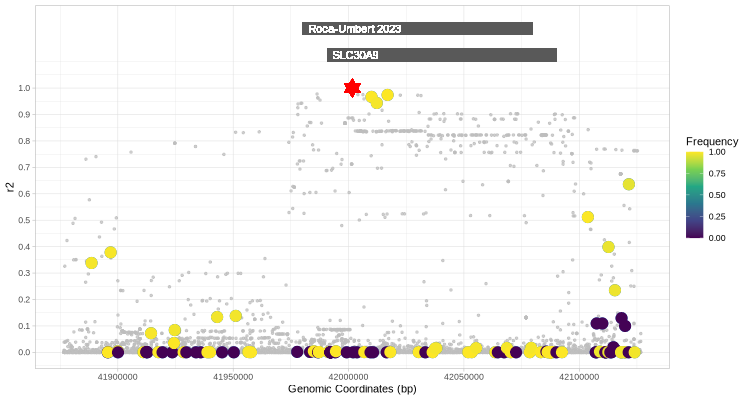

In [22]:
%%R -w 750 -h 400

df %>%
  filter(POS >=  42001654-125000, POS <= 42001654+125000) %>%
  ggplot(aes(x = POS, y = r2)) +
  geom_point(size = 1, alpha = 0.75, color = "gray") +
  geom_point(data = . %>% filter(informative == TRUE), color = "#1874CD", size = 5) +
  geom_point(data = . %>% filter(informative == TRUE), aes(color = freq_alt), size = 5) +
  geom_point(x = 42001654, y = 1, size = 5, shape = 24, fill = "red", color = "red") +
  geom_point(x = 42001654, y = 1, size = 5, shape = 25, fill = "red", color = "red") +
  geom_rect(xmin = 41990530, xmax = 42090461, ymin = 1.1, ymax = 1.15) +
  geom_text(x = 41993030, y = 1.11, label = "SLC30A9", hjust = 0, vjust = 0, color = "white") +
  geom_rect(xmin = 41980000, xmax = 42080000, ymin = 1.2, ymax = 1.25) +
  geom_text(x = 41982500, y = 1.21, label = "Roca-Umbert 2023", hjust = 0, vjust = 0, color = "white") +
  xlab("Genomic Coordinates (bp)") +
    theme_light() +
  scale_color_viridis_c(name = "Frequency", limits = c(0, 1)) +
  scale_y_continuous(breaks = seq(0, 1, by = 0.1))  -> plot

plot

ggsave("plot.png")

plot

# 3. Table 1

In [23]:
%%R

df %>%
  filter(r2 > 0.2) %>%
  filter(informative == TRUE) %>%
  filter(POS >=  42001654-125000, POS <= 42001654+125000) %>%
  select(CHR, POS, r2, Vindija, Chagyrskaya, Altai, Denisova, freq_alt, freq_ref)

   CHR      POS       r2 Vindija Chagyrskaya Altai Denisova  freq_alt
1 chr4 41888616 0.338242     1/1         ./1   0/0      0/0 0.9863702
2 chr4 41896891 0.378157     1/1         ./1   0/0      0/0 0.9894787
3 chr4 42009953 0.966690     0/0         0/0   0/0      1/1 0.9988040
4 chr4 42012245 0.943589     0/0         0/0   0/0      1/1 0.9870870
5 chr4 42016927 0.974047     0/0         0/0   0/0      1/1 0.9988040
6 chr4 42103725 0.511864     0/0         0/0   1/1      0/0 0.9971306
7 chr4 42112654 0.398671     1/1         ./.   1/1      0/0 0.9679579
8 chr4 42115457 0.234911     1/1         1/1   1/1      0/0 0.9732186
9 chr4 42121498 0.635972     1/1         1/1   1/1      0/0 0.9600670
     freq_ref
1 0.462168000
2 0.446830000
3 0.008179960
4 0.000000000
5 0.000511247
6 0.366564000
7 0.397750000
8 0.459100000
9 0.186605000
